In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\sawsu\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df = pd.read_csv('ushape.csv')

In [4]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [6]:
df.columns = ['X', 'Y', 'class']

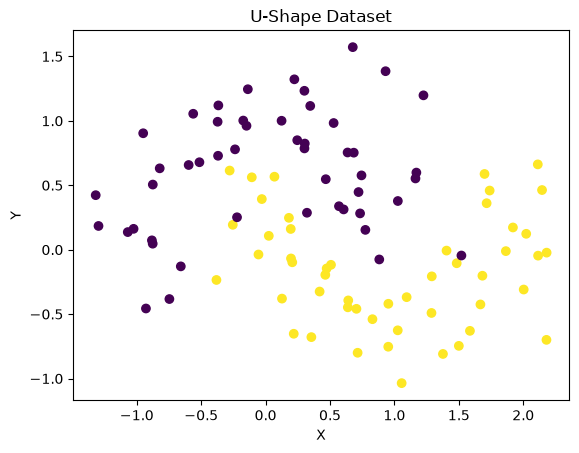

In [7]:
# plt.scatter(df['X'],df['Y'],c=df['class'])

plt.scatter(
    df['X'],
    df['Y'],
    c=df['class']
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('U-Shape Dataset')
plt.show()

In [8]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [9]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [10]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Set parameters to 0
model.get_weights()

[array([[ 0.67570513,  0.6540286 ,  0.5261772 , -0.6545058 ,  0.69099027,
         -0.59842694,  0.06064934, -0.13373429,  0.02613574, -0.07093245],
        [ 0.59375817,  0.35421592, -0.26495212,  0.6722223 , -0.6932487 ,
          0.40196615, -0.3875057 , -0.20504713, -0.2482011 , -0.30433565]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.2095908 ],
        [-0.49001142],
        [ 0.30496305],
        [ 0.39554864],
        [-0.5370223 ],
        [ 0.61583155],
        [-0.65348303],
        [ 0.26484162],
        [-0.25778684],
        [ 0.48489147]], dtype=float32),
 array([0.], dtype=float32)]

In [12]:
initial_weights = model.get_weights()

In [13]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [14]:
model.set_weights(initial_weights)

In [15]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [16]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [17]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 494ms/step - accuracy: 0.4810 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.5063 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5063 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5063 - loss: 0.6930 - val_accuracy: 0.5000 - v

In [18]:
model.get_weights()

[array([[ 0.4358761,  0.4358761,  0.4358761,  0.4358761,  0.4358761,
          0.4358761,  0.4358761,  0.4358761,  0.4358761,  0.4358761],
        [-0.4696099, -0.4696099, -0.4696099, -0.4696099, -0.4696099,
         -0.4696099, -0.4696099, -0.4696099, -0.4696099, -0.4696099]],
       dtype=float32),
 array([-0.13745262, -0.13745262, -0.13745262, -0.13745262, -0.13745262,
        -0.13745262, -0.13745262, -0.13745262, -0.13745262, -0.13745262],
       dtype=float32),
 array([[0.06131837],
        [0.06131837],
        [0.06131837],
        [0.06131837],
        [0.06131837],
        [0.06131837],
        [0.06131837],
        [0.06131837],
        [0.06131837],
        [0.06131837]], dtype=float32),
 array([-0.06510472], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

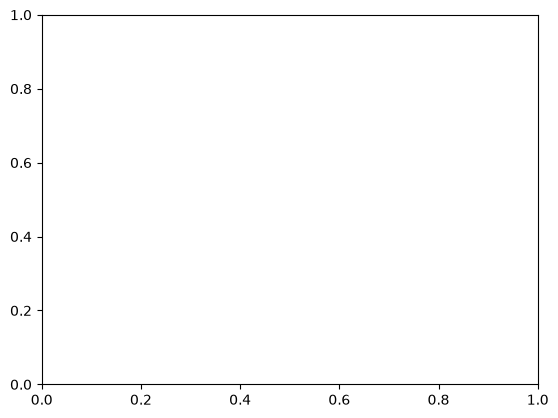

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)